<a href="https://colab.research.google.com/github/Stonetenth2005/Machine-Learning/blob/main/23-PCA/PCA_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Making the dataset

In [11]:
import numpy as np
import pandas as pd

np.random.seed(23)

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40)

In [12]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


Visualizing the dataset

In [13]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

Step 1 : Mean centring using Standard Scaler

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

trf = ColumnTransformer([
    ('scaler',StandardScaler(),['feature1','feature2','feature3'])
],remainder='passthrough')

Step 2 : Covariance Matrix

In [15]:
import numpy as np
covariance_matrix = np.cov(df[['feature1', 'feature2', 'feature3']], rowvar=False)
print(covariance_matrix)

[[1.34076734 0.24528825 0.10420627]
 [0.24528825 1.12566959 0.23643388]
 [0.10420627 0.23643388 1.327287  ]]


In [16]:
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)
print("eigen_values : ", eigen_values)
print("eigen_vectors : ", eigen_vectors)

eigen_values :  [1.65691289 1.22963722 0.90717381]
eigen_vectors :  [[-0.61002583 -0.69239396  0.3853039 ]
 [-0.53982115  0.00718615 -0.84174906]
 [-0.58005311  0.72148387  0.37815264]]


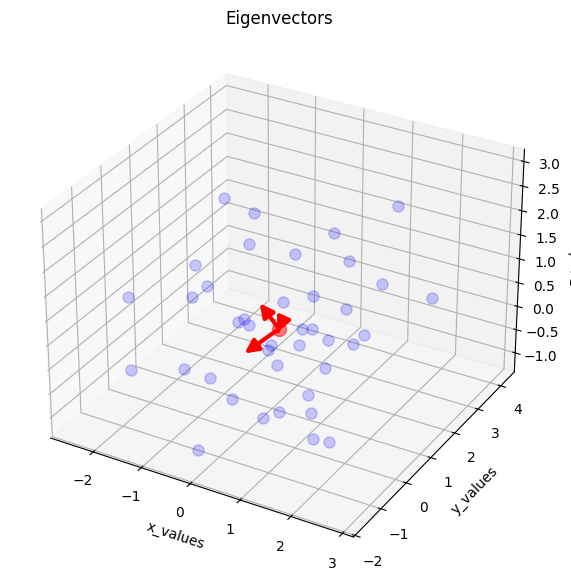

In [22]:
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch


class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        FancyArrowPatch.__init__(self, (0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        FancyArrowPatch.draw(self, renderer)

    def do_3d_projection(self, renderer=None):
        # This method is required by Axes3D for proper z-ordering
        # Return the average z-coordinate as a depth proxy
        return (self._verts3d[2][0] + self._verts3d[2][1]) / 2

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(df['feature1'], df['feature2'], df['feature3'], 'o', markersize=8, color='blue', alpha=0.2)
ax.plot([df['feature1'].mean()], [df['feature2'].mean()], [df['feature3'].mean()], 'o', markersize=10, color='red', alpha=0.5)
for v in eigen_vectors.T:
    # Scale the eigenvectors for better visualization if needed, here just using the original vector length relative to the mean
    a = Arrow3D([df['feature1'].mean(), df['feature1'].mean() + v[0]*eigen_values[np.where((eigen_vectors.T == v).all(axis=1))[0][0]]*0.5], # Scale by eigenvalue for visual relevance
                [df['feature2'].mean(), df['feature2'].mean() + v[1]*eigen_values[np.where((eigen_vectors.T == v).all(axis=1))[0][0]]*0.5],
                [df['feature3'].mean(), df['feature3'].mean() + v[2]*eigen_values[np.where((eigen_vectors.T == v).all(axis=1))[0][0]]*0.5],
                mutation_scale=20, lw=3, arrowstyle="-|>", color="r")
    ax.add_artist(a)
ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.title('Eigenvectors')

plt.show()

Selecting the principle_components from eigen vectors

In [18]:
principle_components = eigen_vectors[0:2]

Transforming data to reduce dimensions

In [19]:
transformed_df = np.dot(df.iloc[:,0:3], principle_components.T)

In [20]:
new_df = pd.DataFrame(transformed_df, columns=['PC1', 'PC2'])
new_df['target'] = df['target']
new_df.head()

,PC1,PC2,target
0,0.502355,1.303153,1
1,0.778695,-1.132295,1
2,-0.569075,-0.164066,1
3,-1.083293,-0.494640,1
4,1.660680,0.843708,1


In [23]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()